In [2]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

esconv_train = pd.read_parquet("../data/processed/esconv/train.parquet")
esconv_val = pd.read_parquet("../data/processed/esconv/val.parquet")
esconv_test = pd.read_parquet("../data/processed/esconv/test.parquet")

esconv = pd.concat([esconv_train, esconv_val, esconv_test], ignore_index=True)

In [3]:
sys_turns = esconv[(esconv['speaker'] == 'sys') & (esconv['strategy'].notna())]

conv_items = sys_turns.groupby('conv_id').apply(
    lambda x: list(set(['emotion_' + x['emotion_type'].iloc[0]] + ['strategy_' + s for s in x['strategy']]))
).tolist()

te = TransactionEncoder()
te_array = te.fit_transform(conv_items)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transactions: {len(df_encoded)}")
print(f"Items: {len(df_encoded.columns)}")
df_encoded.head()

Transactions: 910
Items: 19


/var/folders/gz/7csbppld03bf01hhj_j8cnb80000gn/T/ipykernel_19163/1527437772.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conv_items = sys_turns.groupby('conv_id').apply(


,emotion_anger,emotion_anxiety,emotion_depression,emotion_disgust,emotion_fear,emotion_guilt,emotion_jealousy,emotion_nervousness,emotion_pain,emotion_sadness,emotion_shame,strategy_Affirmation and Reassurance,strategy_Information,strategy_Others,strategy_Providing Suggestions,strategy_Question,strategy_Reflection of feelings,strategy_Restatement or Paraphrasing,strategy_Self-disclosure
0,False,True,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True
1,False,False,True,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True
2,False,True,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True
3,False,False,True,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True
4,False,False,False,True,False,False,False,False,False,False,False,True,True,True,True,True,True,False,True


In [4]:
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

emotion_rules = rules[
    rules['antecedents'].apply(lambda x: any('emotion_' in i for i in x)) &
    rules['consequents'].apply(lambda x: any('strategy_' in i for i in x))
].sort_values('confidence', ascending=False)

print(f"Total rules found: {len(emotion_rules)}")
emotion_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Total rules found: 6152


,antecedents,consequents,support,confidence,lift
1316,"(strategy_Restatement or Paraphrasing, emotion...",(strategy_Question),0.130769,0.991667,1.024309
3949,"(strategy_Restatement or Paraphrasing, strateg...",(strategy_Question),0.123077,0.991150,1.023776
3730,"(strategy_Restatement or Paraphrasing, strateg...",(strategy_Question),0.123077,0.991150,1.023776
4001,"(strategy_Restatement or Paraphrasing, emotion...",(strategy_Question),0.118681,0.990826,1.023441
7374,"(strategy_Affirmation and Reassurance, emotion...",(strategy_Question),0.115385,0.990566,1.023173
7456,"(strategy_Affirmation and Reassurance, emotion...",(strategy_Question),0.113187,0.990385,1.022985
7563,"(emotion_depression, strategy_Restatement or P...",(strategy_Question),0.110989,0.990196,1.022791
3028,"(strategy_Restatement or Paraphrasing, strateg...",(strategy_Question),0.109890,0.990099,1.022690
9937,"(strategy_Affirmation and Reassurance, emotion...",(strategy_Question),0.105495,0.989691,1.022269
6713,"(strategy_Information, strategy_Restatement or...",(strategy_Question),0.104396,0.989583,1.022158


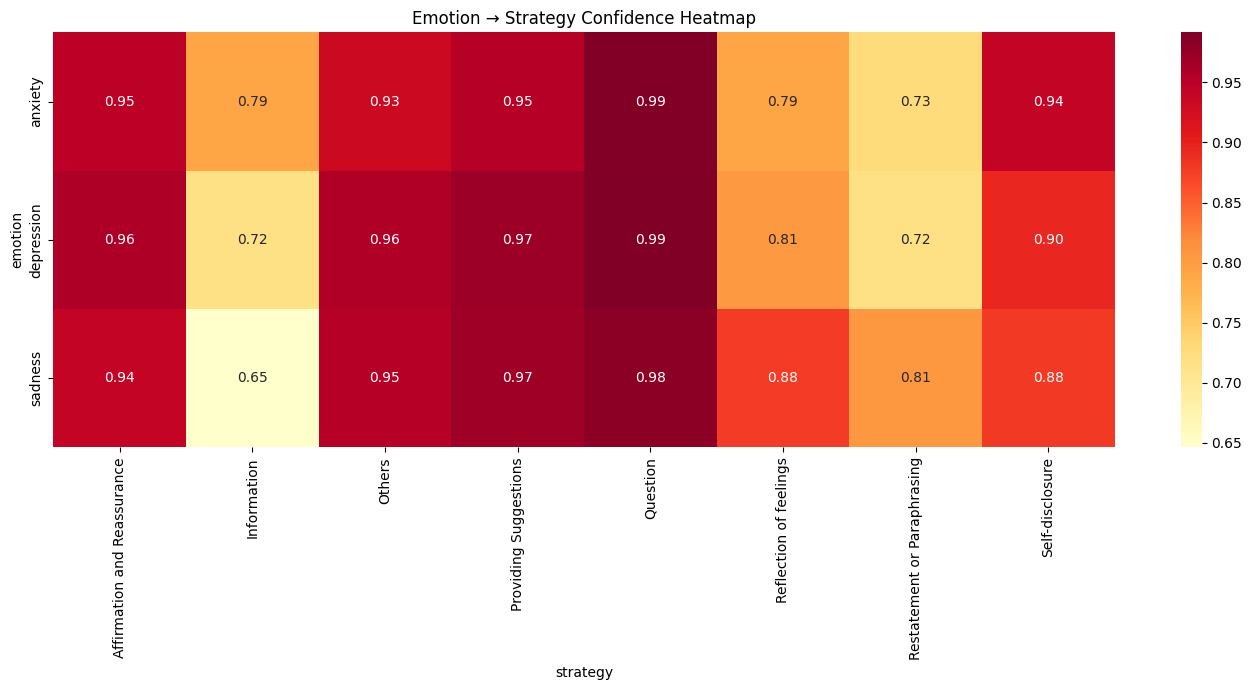

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot_data = []
for _, row in emotion_rules.iterrows():
    emotion = [i.replace('emotion_', '') for i in row['antecedents'] if 'emotion_' in i]
    strategy = [i.replace('strategy_', '') for i in row['consequents'] if 'strategy_' in i]
    if emotion and strategy:
        pivot_data.append({'emotion': emotion[0], 'strategy': strategy[0], 'confidence': row['confidence']})

pivot_df = pd.DataFrame(pivot_data)
pivot_table = pivot_df.pivot_table(index='emotion', columns='strategy', values='confidence', aggfunc='max')

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Emotion → Strategy Confidence Heatmap')
plt.tight_layout()
plt.show()

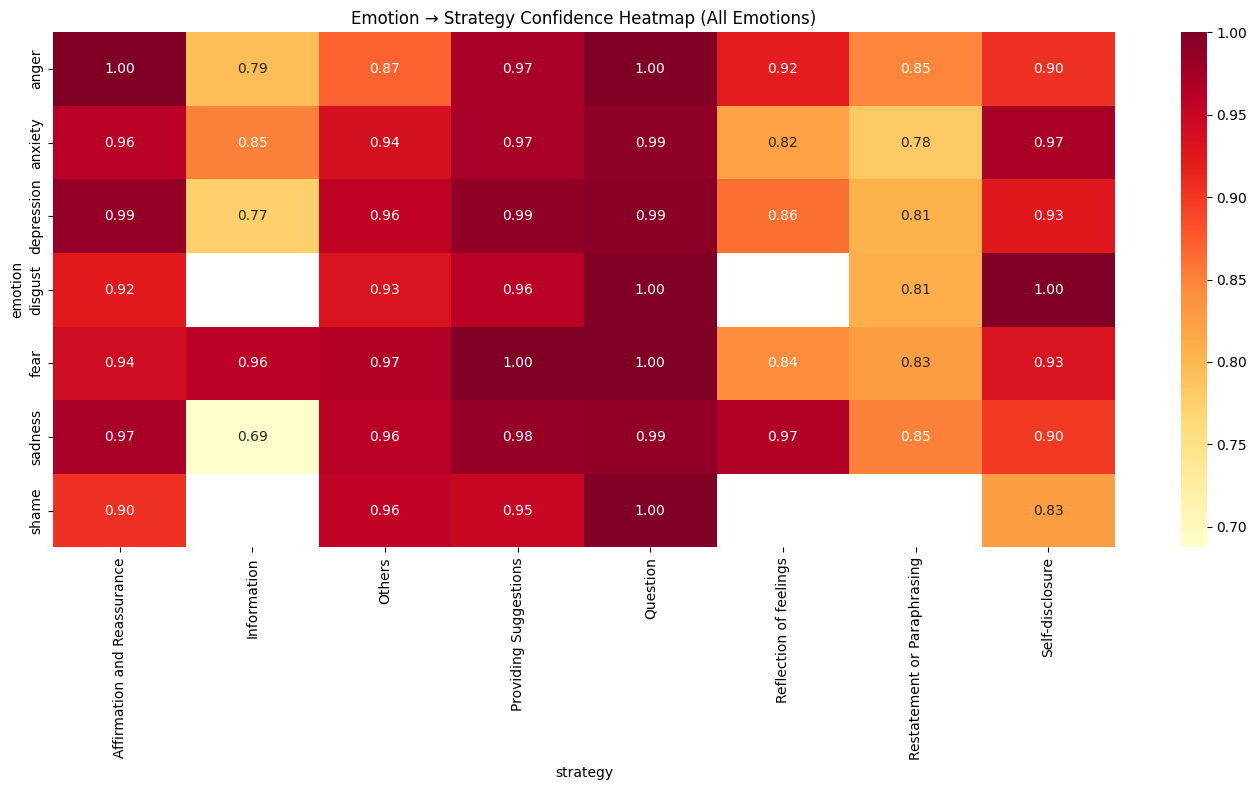

In [6]:
frequent_itemsets2 = apriori(df_encoded, min_support=0.02, use_colnames=True)
rules2 = association_rules(frequent_itemsets2, metric="confidence", min_threshold=0.5)

emotion_rules2 = rules2[
    rules2['antecedents'].apply(lambda x: any('emotion_' in i for i in x)) &
    rules2['consequents'].apply(lambda x: any('strategy_' in i for i in x))
].sort_values('confidence', ascending=False)

pivot_data2 = []
for _, row in emotion_rules2.iterrows():
    emotion = [i.replace('emotion_', '') for i in row['antecedents'] if 'emotion_' in i]
    strategy = [i.replace('strategy_', '') for i in row['consequents'] if 'strategy_' in i]
    if emotion and strategy:
        pivot_data2.append({'emotion': emotion[0], 'strategy': strategy[0], 'confidence': row['confidence']})

pivot_df2 = pd.DataFrame(pivot_data2)
pivot_table2 = pivot_df2.pivot_table(index='emotion', columns='strategy', values='confidence', aggfunc='max')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table2, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Emotion → Strategy Confidence Heatmap (All Emotions)')
plt.tight_layout()
plt.show()

In [8]:
from prefixspan import PrefixSpan

sys_turns = esconv[(esconv['speaker'] == 'sys') & (esconv['strategy'].notna())]

sequences = sys_turns.groupby('conv_id').apply(
    lambda x: x.sort_values('turn_idx')['strategy'].tolist()
).tolist()

print(f"Total sequences: {len(sequences)}")
print(f"Example sequence: {sequences[0]}")

Total sequences: 910
Example sequence: ['Question', 'Others', 'Question', 'Question', 'Reflection of feelings', 'Restatement or Paraphrasing', 'Affirmation and Reassurance', 'Question', 'Information', 'Question', 'Restatement or Paraphrasing', 'Self-disclosure', 'Reflection of feelings', 'Self-disclosure', 'Providing Suggestions', 'Providing Suggestions', 'Affirmation and Reassurance', 'Affirmation and Reassurance', 'Restatement or Paraphrasing', 'Affirmation and Reassurance', 'Restatement or Paraphrasing', 'Providing Suggestions', 'Providing Suggestions', 'Information', 'Providing Suggestions', 'Information', 'Affirmation and Reassurance', 'Reflection of feelings', 'Providing Suggestions', 'Providing Suggestions', 'Affirmation and Reassurance', 'Reflection of feelings', 'Others', 'Providing Suggestions', 'Reflection of feelings', 'Self-disclosure', 'Others', 'Others']


/var/folders/gz/7csbppld03bf01hhj_j8cnb80000gn/T/ipykernel_19163/3514057343.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sequences = sys_turns.groupby('conv_id').apply(


In [9]:
ps = PrefixSpan(sequences)
patterns = ps.frequent(50)
patterns_df = pd.DataFrame(patterns, columns=['support', 'sequence'])
patterns_df = patterns_df[patterns_df['sequence'].apply(len) >= 2].sort_values('support', ascending=False)

print(f"Total frequent patterns found: {len(patterns_df)}")
patterns_df.head(20)

Total frequent patterns found: 2350372


,support,sequence
1258828,789,"[Question, Affirmation and Reassurance]"
1,770,"[Question, Others]"
1450311,760,"[Question, Providing Suggestions]"
124792,749,"[Question, Question]"
2243902,695,"[Affirmation and Reassurance, Others]"
1391963,683,"[Question, Self-disclosure]"
1804414,674,"[Others, Others]"
2337321,669,"[Providing Suggestions, Others]"
1383046,661,"[Question, Affirmation and Reassurance, Others]"
2315728,655,"[Providing Suggestions, Providing Suggestions]"


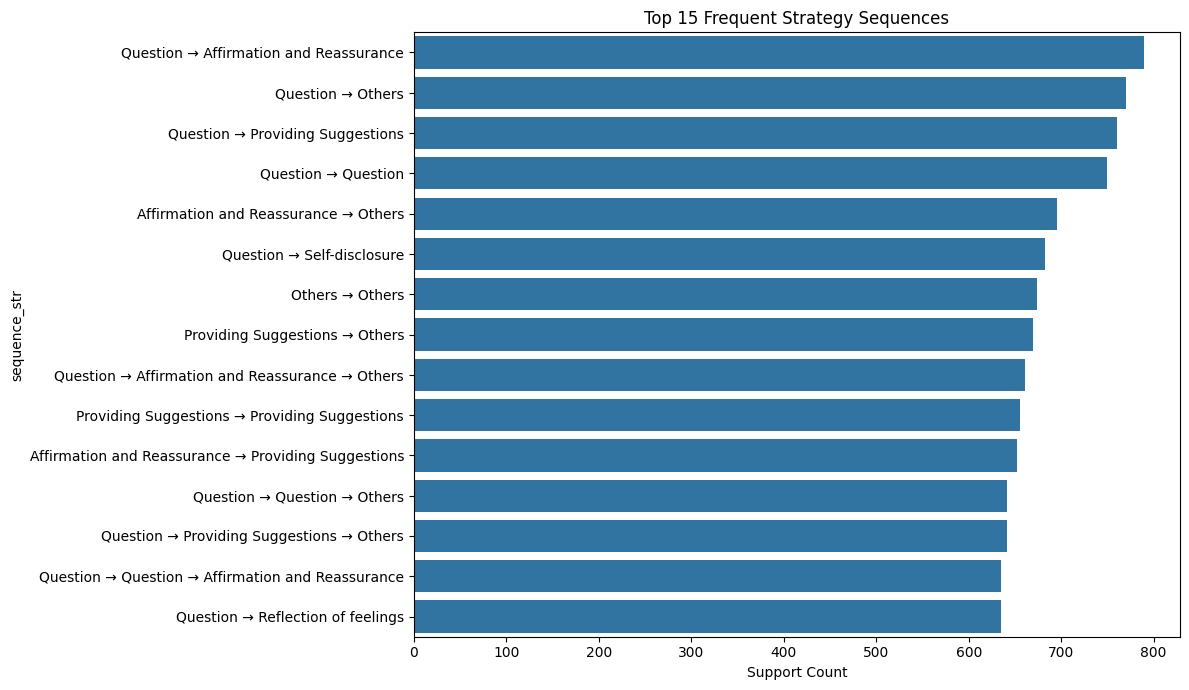

In [10]:
top_patterns = patterns_df.head(15).copy()
top_patterns['sequence_str'] = top_patterns['sequence'].apply(lambda x: ' → '.join(x))

plt.figure(figsize=(12, 7))
sns.barplot(data=top_patterns, x='support', y='sequence_str')
plt.title('Top 15 Frequent Strategy Sequences')
plt.xlabel('Support Count')
plt.tight_layout()
plt.show()

In [12]:
from collections import Counter

def get_bigrams(seq):
    return [f"{seq[i]} → {seq[i+1]}" for i in range(len(seq)-1)]

def get_trigrams(seq):
    return [f"{seq[i]} → {seq[i+1]} → {seq[i+2]}" for i in range(len(seq)-2)]

results = []
for emotion in esconv['emotion_type'].unique():
    conv_ids = esconv[esconv['emotion_type'] == emotion]['conv_id'].unique()
    seqs = sys_turns[sys_turns['conv_id'].isin(conv_ids)].groupby('conv_id').apply(
        lambda x: x.sort_values('turn_idx')['strategy'].tolist(), include_groups=False
    ).tolist()
    
    bigrams = Counter([b for seq in seqs for b in get_bigrams(seq)])
    trigrams = Counter([t for seq in seqs for t in get_trigrams(seq)])
    
    for pattern, count in bigrams.most_common(3):
        results.append({'emotion': emotion, 'pattern': pattern, 'support': count, 'length': 2})
    for pattern, count in trigrams.most_common(3):
        results.append({'emotion': emotion, 'pattern': pattern, 'support': count, 'length': 3})

results_df = pd.DataFrame(results).sort_values(['emotion', 'support'], ascending=[True, False])
print(results_df.to_string(index=False))

    emotion                                                                                 pattern  support  length
      anger                                                                     Question → Question      168       2
      anger                                                                         Others → Others      110       2
      anger                                                  Question → Affirmation and Reassurance      102       2
      anger                                                          Question → Question → Question       49       3
      anger                                       Question → Affirmation and Reassurance → Question       39       3
      anger Affirmation and Reassurance → Affirmation and Reassurance → Affirmation and Reassurance       30       3
    anxiety                                                                     Question → Question      476       2
    anxiety                                                     

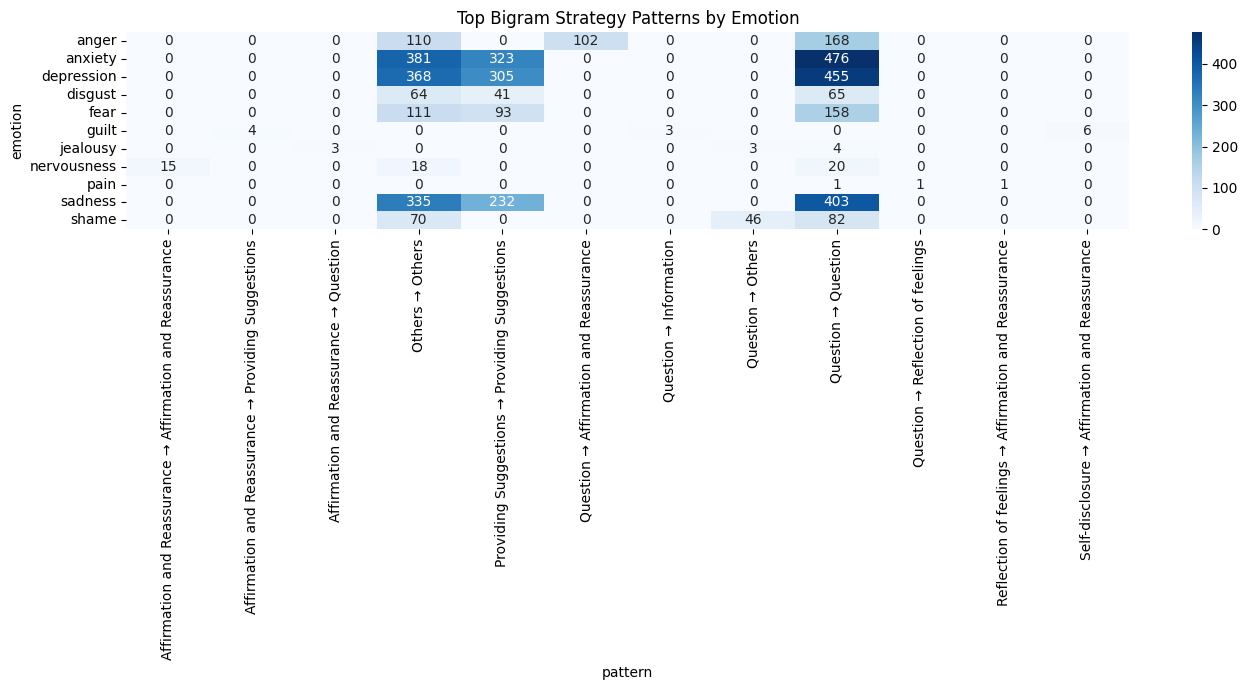

In [13]:
top2 = results_df[results_df['length'] == 2].groupby('emotion').head(3)

plt.figure(figsize=(14, 7))
pivot = top2.pivot_table(index='emotion', columns='pattern', values='support', aggfunc='max').fillna(0)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Top Bigram Strategy Patterns by Emotion')
plt.tight_layout()
plt.show()

In [15]:
import os

os.makedirs("../data/mining", exist_ok=True)

results_df.to_parquet("../data/mining/sequential_patterns.parquet", index=False)

rules_save = emotion_rules2.copy()
rules_save['antecedents'] = rules_save['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_save['consequents'] = rules_save['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules_save[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_parquet("../data/mining/association_rules.parquet", index=False)